In [1]:
%pip install nltk

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 328.9 kB/s eta 0:00:04
   ----------- ---------------------------- 0.5/1.8 MB 328.9 kB/s eta 0:00:04
   ----------- ---------------------------- 0.5/1.8 MB 328.9 kB/s eta 0:00:04
   ----------------- ---------------------- 0.8/1.8 MB 356.9 kB/s eta 0:00:03
   ----------------- ---------------------- 0.8/1.8 MB 356.9 kB/s eta 0:00:03
   ----------------- ---------------------- 0.8/1.8 MB 356

In [2]:
import numpy as np
import pandas as pd
import nltk
import re

nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

print("Libraries imported successfully")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Hp\AppData\Roaming\nltk_data...


Libraries imported successfully


[nltk_data]   Unzipping corpora\stopwords.zip.


In [4]:
import os

print(os.path.exists(r"C:\Users\Hp\Downloads\Restaurant_Reviews.tsv"))

True


In [5]:
df = pd.read_csv(
    r"C:\Users\Hp\Downloads\Restaurant_Reviews.tsv",
    delimiter="\t",
    quoting=3
)

print(df.head())
print(df.shape)

                                              Review  Liked
0                           Wow... Loved this place.      1
1                                 Crust is not good.      0
2          Not tasty and the texture was just nasty.      0
3  Stopped by during the late May bank holiday of...      1
4  The selection on the menu was great and so wer...      1
(1000, 2)


In [6]:
corpus = []

for i in range(0, 1000):

    # Remove special characters
    review = re.sub(
        pattern='[^a-zA-Z]',
        repl=' ',
        string=df['Review'][i]
    )

    # Convert to lowercase
    review = review.lower()

    # Split into words
    review_words = review.split()

    # Remove stopwords
    review_words = [
        word for word in review_words
        if word not in set(stopwords.words('english'))
    ]

    # Stemming
    ps = PorterStemmer()
    review = [ps.stem(word) for word in review_words]

    # Join the words
    review = ' '.join(review)

    corpus.append(review)

print(corpus[0:10])

['wow love place', 'crust good', 'tasti textur nasti', 'stop late may bank holiday rick steve recommend love', 'select menu great price', 'get angri want damn pho', 'honeslti tast fresh', 'potato like rubber could tell made ahead time kept warmer', 'fri great', 'great touch']


In [7]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=1500)

X = cv.fit_transform(corpus).toarray()

y = df.iloc[:, 1].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 1500)
y shape: (1000,)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=0
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 1500)
Testing data: (200, 1500)


In [9]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=35)

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [10]:
print("Model accuracy:", model.score(X_test, y_test))

Model accuracy: 0.715


In [11]:
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

score1 = accuracy_score(y_test, y_pred)
score2 = precision_score(y_test, y_pred)
score3 = recall_score(y_test, y_pred)

print("---- Scores ----")
print("Accuracy score is: {}%".format(round(score1 * 100, 2)))
print("Precision score is: {}".format(round(score2, 2)))
print("Recall score is: {}".format(round(score3, 2)))

---- Scores ----
Accuracy score is: 71.5%
Precision score is: 0.84
Recall score is: 0.55


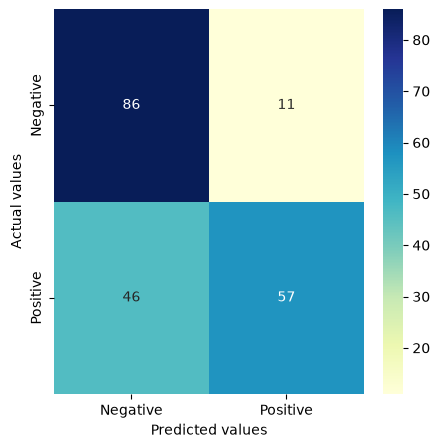

In [12]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 5))

sns.heatmap(
    cm,
    annot=True,
    cmap="YlGnBu",
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.xlabel('Predicted values')
plt.ylabel('Actual values')

plt.show()

In [13]:
best_accuracy = 0.0
n_estimators = 5

for i in np.arange(1, 30, 2):

    temp_classifier = RandomForestClassifier(n_estimators=i)

    temp_classifier.fit(X_train, y_train)

    temp_y_pred = temp_classifier.predict(X_test)

    score = accuracy_score(y_test, temp_y_pred)

    print(
        "Accuracy score for n_estimators={} is: {}%".format(
            round(i, 1),
            round(score * 100, 2)
        )
    )

    if score > best_accuracy:
        best_accuracy = score
        n_estimators_val = i

print()
print(
    'The best accuracy is {}% with n_estimators value as {}'.format(
        round(best_accuracy * 100, 2),
        round(n_estimators_val, 1)
    )
)

Accuracy score for n_estimators=1 is: 68.0%
Accuracy score for n_estimators=3 is: 69.5%
Accuracy score for n_estimators=5 is: 71.5%
Accuracy score for n_estimators=7 is: 67.5%
Accuracy score for n_estimators=9 is: 68.5%
Accuracy score for n_estimators=11 is: 69.5%
Accuracy score for n_estimators=13 is: 69.5%
Accuracy score for n_estimators=15 is: 69.5%
Accuracy score for n_estimators=17 is: 70.0%
Accuracy score for n_estimators=19 is: 68.5%
Accuracy score for n_estimators=21 is: 65.0%
Accuracy score for n_estimators=23 is: 69.5%
Accuracy score for n_estimators=25 is: 71.5%
Accuracy score for n_estimators=27 is: 69.5%
Accuracy score for n_estimators=29 is: 72.0%

The best accuracy is 72.0% with n_estimators value as 29


In [14]:
model = RandomForestClassifier(n_estimators=n_estimators_val)

model.fit(X_train, y_train)

print("Optimized model trained successfully")
print("Best n_estimators:", n_estimators_val)

Optimized model trained successfully
Best n_estimators: 29
